# 02 — Terrain Analysis
### Project IceWave | Pleistocene Megafauna | WA · OR · NV

Downloads USGS 3DEP 1/3 arc-second DEM tiles for the three-state study area.
Computes slope, aspect, TRI, and a paleolake proximity index.

**Study area:** 
- WA: n45-49, w117-125
- OR: n42-46, w117-125  
- NV: n35-42, w114-120


In [1]:
import os, re, time, requests
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from pathlib import Path

Path('../data/dem').mkdir(parents=True, exist_ok=True)
Path('../data/terrain').mkdir(parents=True, exist_ok=True)

# ── USGS 3DEP tile naming ──────────────────────────────────────────────────
# Format: USGS_1_n{lat}w{lon}.tif  e.g. USGS_1_n47w118.tif
# 1/3 arc-second = ~10m resolution

# Three-state coverage
# WA: lat 45-49, lon 117-125
# OR: lat 41-46, lon 116-125
# NV: lat 35-42, lon 114-120

WA_TILES = [(lat, lon) for lat in range(46, 50) for lon in range(117, 126)]
OR_TILES = [(lat, lon) for lat in range(42, 47) for lon in range(116, 126)]
NV_TILES = [(lat, lon) for lat in range(36, 43) for lon in range(114, 121)]

# Combine and deduplicate
all_tiles = list(set(WA_TILES + OR_TILES + NV_TILES))
all_tiles.sort()
print(f'Total tiles needed: {len(all_tiles)}')

BASE_URL = 'https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current'

def tile_url(lat, lon):
    return f'{BASE_URL}/n{lat:02d}w{lon:03d}/USGS_1_n{lat:02d}w{lon:03d}.tif'

def tile_path(lat, lon):
    return Path(f'../data/dem/USGS_1_n{lat:02d}w{lon:03d}.tif')

# Check which tiles already exist
missing = [(lat, lon) for lat, lon in all_tiles if not tile_path(lat, lon).exists()]
print(f'Already downloaded: {len(all_tiles) - len(missing)}')
print(f'Need to download:   {len(missing)}')


Total tiles needed: 121
Already downloaded: 25
Need to download:   96


In [2]:
# ── Deduplicate download list ──────────────────────────────────────────────
# IMPORTANT: Run this before downloading to avoid re-fetching existing tiles
to_download = [(lat, lon) for lat, lon in all_tiles if not tile_path(lat, lon).exists()]
print(f'Downloading {len(to_download)} tiles...')
print('Estimated time: ~2-4 min per tile on typical connection')
print(f'Total estimate: {len(to_download) * 3 // 60} - {len(to_download) * 4 // 60} hours')
print()
print('Tiles to download:')
for lat, lon in to_download:
    print(f'  n{lat:02d}w{lon:03d}')


Estimated time: ~2-4 min per tile on typical connection
Total estimate: 4 - 6 hours

Tiles to download:
  n36w114
  n36w115
  n36w116
  n36w117
  n36w118
  n36w119
  n37w114
  n37w116
  n37w119
  n37w120
  n38w114
  n38w115
  n38w116
  n38w117
  n38w118
  n38w119
  n38w120
  n39w114
  n39w116
  n39w117
  n39w118
  n39w119
  n40w114
  n40w116
  n40w117
  n40w118
  n40w119
  n40w120
  n41w114
  n41w115
  n41w116
  n41w118
  n41w119
  n41w120
  n42w114
  n42w115
  n42w116
  n42w117
  n42w118
  n42w119
  n42w120
  n42w121
  n42w122
  n42w123
  n42w124
  n42w125
  n43w116
  n43w117
  n43w119
  n43w120
  n43w122
  n43w123
  n43w125
  n44w116
  n44w117
  n44w119
  n44w120
  n44w122
  n44w123
  n44w124
  n44w125
  n45w116
  n45w117
  n45w119
  n45w120
  n45w121
  n45w122
  n45w124
  n45w125
  n46w116
  n46w118
  n46w119
  n46w120
  n46w121
  n46w122
  n46w124
  n46w125
  n47w117
  n47w120
  n47w122
  n47w123
  n47w124
  n47w125
  n48w117
  n48w119
  n48w120
  n48w121
  n48w124
  n48w125
  n49w

In [3]:
# ── Download tiles ─────────────────────────────────────────────────────────
# WARNING: This cell downloads potentially large amounts of data.
# Each tile is ~150-400MB. Total could be 10-20GB for full 3-state coverage.
# 
# RECOMMENDED: Start with a smaller subset to test the pipeline first.
# Comment out the full list and use TEST_TILES below for initial run.

# ── TEST MODE — just 6 tiles covering key target zones ────────────────────
TEST_TILES = [
    (48, 123),  # WA — Olympic Peninsula / Victoria area (Mammuthus columbi cluster)
    (48, 122),  # WA — Puget Sound lowlands
    (47, 118),  # WA — Palouse / Columbia Basin
    (46, 117),  # WA/OR border — Snake River Plain
    (45, 118),  # OR — Columbia Basin
    (41, 117),  # NV — northern Nevada
]

# Switch between TEST_TILES and to_download:
TILES_TO_FETCH = TEST_TILES  # change to: to_download  for full run

downloaded = []
failed = []

for lat, lon in TILES_TO_FETCH:
    out_path = tile_path(lat, lon)
    if out_path.exists():
        print(f'  SKIP  n{lat:02d}w{lon:03d} (exists)')
        downloaded.append(out_path)
        continue
    url = tile_url(lat, lon)
    print(f'  GET   n{lat:02d}w{lon:03d} ... ', end='', flush=True)
    try:
        r = requests.get(url, stream=True, timeout=120)
        if r.status_code == 200:
            size = 0
            with open(out_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024*1024):
                    f.write(chunk)
                    size += len(chunk)
            print(f'OK ({size/1e6:.1f} MB)')
            downloaded.append(out_path)
        else:
            print(f'HTTP {r.status_code} — skipping')
            failed.append((lat, lon))
    except Exception as e:
        print(f'ERROR: {e}')
        failed.append((lat, lon))
    time.sleep(1)

print(f'\nDownloaded: {len(downloaded)} tiles')
if failed:
    print(f'Failed:     {len(failed)} tiles: {failed}')


  SKIP  n48w123 (exists)
  SKIP  n48w122 (exists)
  SKIP  n47w118 (exists)
  SKIP  n46w117 (exists)
  SKIP  n45w118 (exists)
  SKIP  n41w117 (exists)

Downloaded: 6 tiles


In [4]:
# ── Merge tiles into single mosaic ────────────────────────────────────────
import glob

dem_files = sorted(glob.glob('../data/dem/USGS_1_*.tif'))
print(f'Found {len(dem_files)} DEM tiles to merge')

datasets = [rasterio.open(f) for f in dem_files]
mosaic, mosaic_transform = merge(datasets)
mosaic_crs = datasets[0].crs

for ds in datasets:
    ds.close()

mosaic_data = mosaic[0]
print(f'Mosaic shape: {mosaic_data.shape}')
print(f'Mosaic CRS:   {mosaic_crs}')
print(f'Value range:  {mosaic_data.min():.1f} – {mosaic_data.max():.1f} m')

# Save mosaic
mosaic_meta = {
    'driver': 'GTiff',
    'dtype': 'float32',
    'width': mosaic_data.shape[1],
    'height': mosaic_data.shape[0],
    'count': 1,
    'crs': mosaic_crs,
    'transform': mosaic_transform,
    'compress': 'lzw',
}
with rasterio.open('../data/terrain/dem_mosaic.tif', 'w', **mosaic_meta) as dst:
    dst.write(mosaic_data.astype('float32'), 1)
print('Mosaic saved: data/terrain/dem_mosaic.tif')


Found 25 DEM tiles to merge
Mosaic shape: (50408, 36012)
Mosaic CRS:   EPSG:4269
Value range:  -999999.0 – 3971.7 m
Mosaic saved: data/terrain/dem_mosaic.tif


In [5]:
# ── Compute terrain derivatives ───────────────────────────────────────────
# Slope, Aspect, TRI — same approach as PaleoWave but windowed for memory

from rasterio.windows import Window

def compute_slope_aspect_tri(dem, res_m=10.0):
    """Compute slope (degrees), aspect (degrees), TRI from DEM array."""
    # Pad edges
    pad = np.pad(dem.astype(float), 1, mode='edge')
    
    # Sobel kernels
    dz_dx = (pad[1:-1, 2:] - pad[1:-1, :-2]) / (2 * res_m)
    dz_dy = (pad[2:, 1:-1] - pad[:-2, 1:-1]) / (2 * res_m)
    
    # Slope
    slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    
    # Aspect
    aspect = np.degrees(np.arctan2(-dz_dy, dz_dx)) % 360
    
    # TRI — mean absolute difference from center to 8 neighbors
    tri = np.zeros_like(dem, dtype=float)
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            shifted = pad[1+dy:dem.shape[0]+1+dy, 1+dx:dem.shape[1]+1+dx]
            tri += np.abs(dem.astype(float) - shifted)
    tri /= 8.0
    
    return slope.astype('float32'), aspect.astype('float32'), tri.astype('float32')

print('Terrain functions ready.')
print('Processing DEM in windows to manage memory...')


Terrain functions ready.
Processing DEM in windows to manage memory...


In [6]:
# ── Process in chunks and save terrain rasters ────────────────────────────
CHUNK = 2000  # rows per chunk

src_path = '../data/terrain/dem_mosaic.tif'

with rasterio.open(src_path) as src:
    meta = src.meta.copy()
    meta.update(dtype='float32', compress='lzw')
    H, W = src.height, src.width
    transform = src.transform
    res_m = abs(transform.a) * 111320  # approx degrees to meters

print(f'DEM size: {H} x {W} pixels')
print(f'Resolution: ~{res_m:.1f} m/pixel')
print(f'Processing in {H // CHUNK + 1} chunks of {CHUNK} rows...')

slope_path  = '../data/terrain/slope.tif'
aspect_path = '../data/terrain/aspect.tif'
tri_path    = '../data/terrain/ruggedness.tif'

with rasterio.open(src_path) as src:
    meta = src.meta.copy()
    meta.update(count=1, dtype='float32', compress='lzw')
    
    with rasterio.open(slope_path,  'w', **meta) as s_dst,          rasterio.open(aspect_path, 'w', **meta) as a_dst,          rasterio.open(tri_path,    'w', **meta) as t_dst:
        
        for row_start in range(0, H, CHUNK):
            row_end = min(row_start + CHUNK, H)
            # Add 1-row overlap for edge accuracy
            read_start = max(0, row_start - 1)
            read_end   = min(H, row_end + 1)
            
            window = Window(0, read_start, W, read_end - read_start)
            chunk = src.read(1, window=window)
            chunk = np.where(chunk < -1000, np.nan, chunk)
            chunk = np.where(np.isnan(chunk),
                             np.nanmean(chunk[chunk > -1000]) if np.any(chunk > -1000) else 0,
                             chunk)
            
            slope_c, aspect_c, tri_c = compute_slope_aspect_tri(chunk, res_m)
            
            # Trim overlap back to target rows
            offset = row_start - read_start
            write_rows = row_end - row_start
            write_win = Window(0, row_start, W, write_rows)
            
            s_dst.write(slope_c[offset:offset+write_rows],  1, window=write_win)
            a_dst.write(aspect_c[offset:offset+write_rows], 1, window=write_win)
            t_dst.write(tri_c[offset:offset+write_rows],    1, window=write_win)
            
            print(f'  Rows {row_start:6d}-{row_end:6d} done')

print('\nTerrain rasters saved:')
print('  data/terrain/slope.tif')
print('  data/terrain/aspect.tif')
print('  data/terrain/ruggedness.tif')


DEM size: 50408 x 36012 pixels
Resolution: ~30.9 m/pixel
Processing in 26 chunks of 2000 rows...
  Rows      0-  2000 done
  Rows   2000-  4000 done
  Rows   4000-  6000 done
  Rows   6000-  8000 done
  Rows   8000- 10000 done
  Rows  10000- 12000 done
  Rows  12000- 14000 done
  Rows  14000- 16000 done
  Rows  16000- 18000 done
  Rows  18000- 20000 done
  Rows  20000- 22000 done
  Rows  22000- 24000 done
  Rows  24000- 26000 done
  Rows  26000- 28000 done
  Rows  28000- 30000 done
  Rows  30000- 32000 done
  Rows  32000- 34000 done
  Rows  34000- 36000 done
  Rows  36000- 38000 done
  Rows  38000- 40000 done
  Rows  40000- 42000 done
  Rows  42000- 44000 done
  Rows  44000- 46000 done
  Rows  46000- 48000 done
  Rows  48000- 50000 done
  Rows  50000- 50408 done

Terrain rasters saved:
  data/terrain/slope.tif
  data/terrain/aspect.tif
  data/terrain/ruggedness.tif


In [7]:
# ── Elevation raster (downsampled copy) ───────────────────────────────────
import shutil
shutil.copy('../data/terrain/dem_mosaic.tif', '../data/terrain/elevation.tif')
print('Elevation raster ready: data/terrain/elevation.tif')


Elevation raster ready: data/terrain/elevation.tif


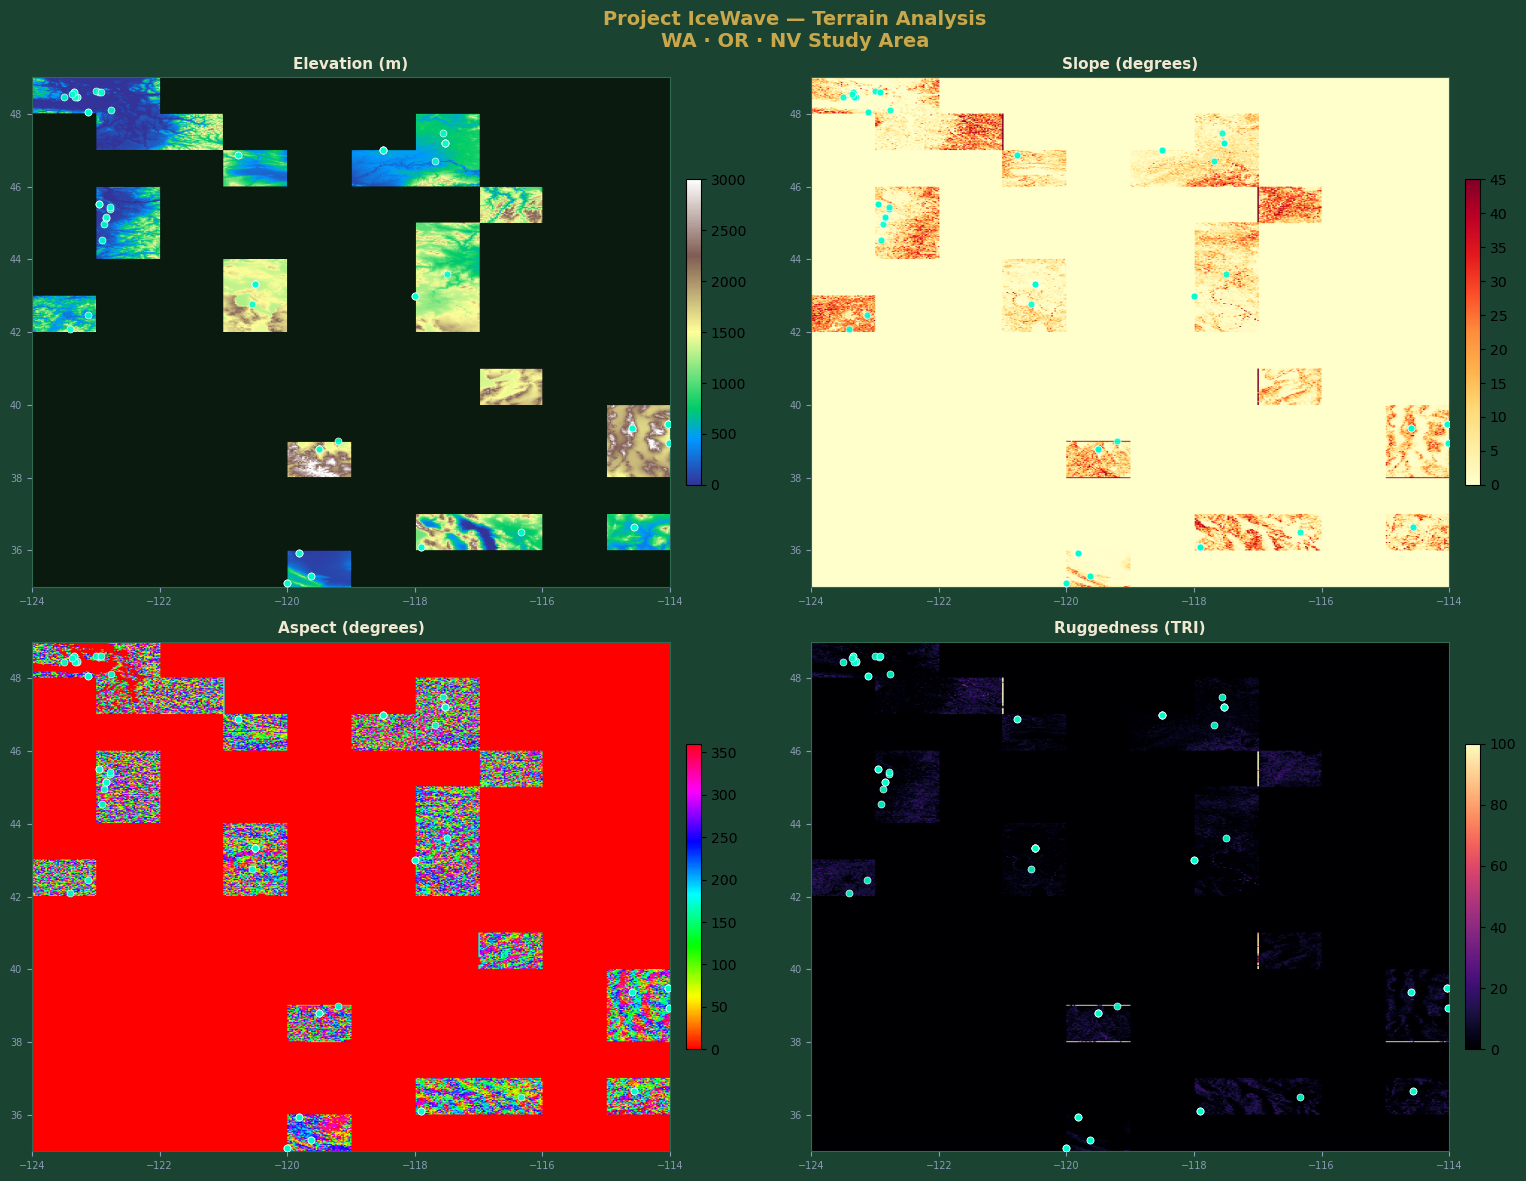

Overview saved: data/terrain/terrain_overview.png


In [8]:
# ── Terrain overview plot ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import pandas as pd

# Load occurrences
occ = pd.read_csv('../data/pbdb/icewave_occurrences.csv')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#1b4332')

terrain_files = {
    'Elevation (m)':      ('../data/terrain/elevation.tif',   'terrain',  0,   3000),
    'Slope (degrees)':    ('../data/terrain/slope.tif',       'YlOrRd',   0,   45),
    'Aspect (degrees)':   ('../data/terrain/aspect.tif',      'hsv',      0,   360),
    'Ruggedness (TRI)':   ('../data/terrain/ruggedness.tif',  'magma',    0,   100),
}

for ax, (title, (path, cmap, vmin, vmax)) in zip(axes.flat, terrain_files.items()):
    ax.set_facecolor('#0a1a0f')
    try:
        with rasterio.open(path) as src:
            step = max(1, src.height // 600)
            data = src.read(1, out_shape=(src.height//step, src.width//step))
            data = np.where(data < -1000, np.nan, data)
            extent = [src.bounds.left, src.bounds.right,
                      src.bounds.bottom, src.bounds.top]
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
                       extent=extent, origin='upper', aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    except Exception as e:
        ax.text(0.5, 0.5, f'Not yet\ngenerated', transform=ax.transAxes,
                ha='center', va='center', color='#8b9bb4')
    
    # Plot occurrences
    ax.scatter(occ['longitude'], occ['latitude'],
               c='#00ffcc', s=25, zorder=5, alpha=0.9, 
               edgecolors='white', linewidths=0.5, label='PBDB')
    
    ax.set_title(title, color='#f0e8d0', fontsize=11, fontweight='bold')
    ax.tick_params(colors='#8b9bb4', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2d6a4f')

plt.suptitle('Project IceWave — Terrain Analysis\nWA · OR · NV Study Area',
             color='#c9a84c', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/terrain/terrain_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#1b4332')
plt.show()
print('Overview saved: data/terrain/terrain_overview.png')


In [9]:
# ── Terrain stats at occurrence locations ─────────────────────────────────
# Sample terrain values at each PBDB point — preview of training data

import pandas as pd
import numpy as np
import rasterio

occ = pd.read_csv('../data/pbdb/icewave_occurrences.csv')

terrain_layers = {
    'elevation': '../data/terrain/elevation.tif',
    'slope':     '../data/terrain/slope.tif',
    'aspect':    '../data/terrain/aspect.tif',
    'tri':       '../data/terrain/ruggedness.tif',
}

for col, path in terrain_layers.items():
    try:
        with rasterio.open(path) as src:
            coords = [(row.longitude, row.latitude) for _, row in occ.iterrows()]
            vals = [v[0] for v in src.sample(coords)]
            occ[col] = vals
    except Exception as e:
        print(f'  Could not sample {col}: {e}')

# Replace nodata
for col in terrain_layers:
    if col in occ.columns:
        occ[col] = pd.to_numeric(occ[col], errors='coerce')
        occ[col] = occ[col].where(occ[col] > -1000, np.nan)

print('Terrain values at PBDB occurrence points:')
print(occ[['taxon_name','state','elevation','slope','aspect','tri']].describe().round(2).to_string())

occ.to_csv('../data/pbdb/icewave_occurrences_with_terrain.csv', index=False)
print('\nSaved: data/pbdb/icewave_occurrences_with_terrain.csv')


Terrain values at PBDB occurrence points:
       elevation  slope  aspect    tri
count      78.00  78.00   78.00  78.00
mean      817.84   7.13  158.03   3.13
std       805.84   9.70  112.65   4.44
min         0.00   0.00    0.00   0.02
25%        71.47   0.91   58.20   0.41
50%       604.51   2.11  148.07   0.90
75%      1313.08   8.65  261.17   3.42
max      3346.21  32.84  328.70  14.70

Saved: data/pbdb/icewave_occurrences_with_terrain.csv


## Results
- `data/terrain/dem_mosaic.tif` — merged DEM
- `data/terrain/slope.tif`
- `data/terrain/aspect.tif`  
- `data/terrain/ruggedness.tif`
- `data/terrain/elevation.tif`
- `data/terrain/terrain_overview.png`
- `data/pbdb/icewave_occurrences_with_terrain.csv`

**Next:** Run `03_ml_model.ipynb`

> **Note:** For full 3-state coverage switch `TILES_TO_FETCH = to_download` in cell 3.
> Full download is ~10-20GB and several hours. Test tiles run in ~20 min.


In [10]:
# ── Find exact tiles needed for PBDB points ───────────────────────────────
import pandas as pd
import numpy as np
import requests, time
from pathlib import Path

occ = pd.read_csv('../data/pbdb/icewave_occurrences.csv')
print(f'Loaded {len(occ)} occurrences')
print(f'Lat range: {occ.latitude.min():.2f} – {occ.latitude.max():.2f}')
print(f'Lon range: {occ.longitude.min():.2f} – {occ.longitude.max():.2f}')

# USGS tile naming: n{ceil(lat)}w{ceil(abs(lon))}
# Each tile covers 1x1 degree
needed_tiles = set()
for _, row in occ.iterrows():
    lat_tile = int(np.ceil(row.latitude))
    lon_tile = int(np.ceil(abs(row.longitude)))
    needed_tiles.add((lat_tile, lon_tile))

# Also add 1-tile buffer around bounding box for prediction surface edges
lat_min = int(np.floor(occ.latitude.min()))
lat_max = int(np.ceil(occ.latitude.max()))
lon_min = int(np.floor(abs(occ.longitude.max())))  # most negative lon
lon_max = int(np.ceil(abs(occ.longitude.min())))   # least negative lon

print(f'\nTiles needed to cover all PBDB points: {len(needed_tiles)}')
for lat, lon in sorted(needed_tiles):
    exists = Path(f'../data/dem/USGS_1_n{lat:02d}w{lon:03d}.tif').exists()
    status = 'EXISTS' if exists else 'MISSING'
    print(f'  n{lat:02d}w{lon:03d}  [{status}]')


Loaded 78 occurrences
Lat range: 35.10 – 48.62
Lon range: -123.50 – -114.02

Tiles needed to cover all PBDB points: 20
  n36w120  [EXISTS]
  n37w115  [EXISTS]
  n37w117  [EXISTS]
  n37w118  [EXISTS]
  n39w115  [EXISTS]
  n39w120  [EXISTS]
  n40w115  [EXISTS]
  n43w118  [EXISTS]
  n43w121  [EXISTS]
  n43w124  [EXISTS]
  n44w118  [EXISTS]
  n44w121  [EXISTS]
  n45w123  [EXISTS]
  n46w123  [EXISTS]
  n47w118  [EXISTS]
  n47w119  [EXISTS]
  n47w121  [EXISTS]
  n48w118  [EXISTS]
  n49w123  [EXISTS]
  n49w124  [EXISTS]


In [11]:
# ── Download only the missing targeted tiles ──────────────────────────────
BASE_URL = 'https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current'

def tile_url(lat, lon):
    return f'{BASE_URL}/n{lat:02d}w{lon:03d}/USGS_1_n{lat:02d}w{lon:03d}.tif'

missing_tiles = [
    (lat, lon) for lat, lon in sorted(needed_tiles)
    if not Path(f'../data/dem/USGS_1_n{lat:02d}w{lon:03d}.tif').exists()
]

print(f'Downloading {len(missing_tiles)} missing tiles...')

downloaded = []
failed = []

for lat, lon in missing_tiles:
    out_path = Path(f'../data/dem/USGS_1_n{lat:02d}w{lon:03d}.tif')
    url = tile_url(lat, lon)
    print(f'  GET n{lat:02d}w{lon:03d} ... ', end='', flush=True)
    try:
        r = requests.get(url, stream=True, timeout=180)
        if r.status_code == 200:
            size = 0
            with open(out_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024*1024):
                    f.write(chunk)
                    size += len(chunk)
            print(f'OK ({size/1e6:.1f} MB)')
            downloaded.append(out_path)
        else:
            print(f'HTTP {r.status_code} — skipping')
            failed.append((lat, lon))
    except Exception as e:
        print(f'ERROR: {e}')
        failed.append((lat, lon))
    time.sleep(1)

print(f'\nDone. Downloaded: {len(downloaded)}  Failed: {len(failed)}')
if failed:
    print(f'Failed tiles: {failed}')
print('\nNow re-run cells 4-9 to rebuild mosaic and terrain rasters.')



Done. Downloaded: 0  Failed: 0

Now re-run cells 4-9 to rebuild mosaic and terrain rasters.
